### Importing Libraries and Data

In [52]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import re

pd.set_option('display.max_columns', None)

In [53]:
df = pd.read_csv('A:/CODES/PROJECTS/appartments/Data/gurgaon/properties_cleaned_v2.csv').drop_duplicates()
df.head()

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
0,flat,signature global solera,sector 107,0.36,6581.0,547.0,Carpet area: 547 (50.82 sq.m.),2,2,2,8.0,South-East,Relatively New,NaN,NaN,547.0,0,0,0,0,0,0,45
1,flat,tulip yellow,sector 69,1.80,10563.0,1704.0,Carpet area: 1704 (158.31 sq.m.),3,3,3,14.0,East,Under Construction,NaN,NaN,1704.0,0,0,0,0,0,0,49
2,flat,tulip violet,sector 69,1.75,9459.0,1850.0,Carpet area: 1850 (171.87 sq.m.),3,4,2,0.0,East,Relatively New,NaN,NaN,1850.0,0,0,0,0,0,2,174
3,flat,ardee city,sector 52,1.50,9146.0,1640.0,Super Built up area 1640(152.36 sq.m.),4,4,3,3.0,NaN,Old Property,1640.0,NaN,NaN,0,0,0,0,0,0,65
4,house,independent,sector 7,3.85,14650.0,2628.0,Plot area 292(244.15 sq.m.),4,4,3,3.0,North-West,Old Property,NaN,2628.0,NaN,0,0,0,0,0,0,27


### property_type vs price

<Axes: xlabel='property_type', ylabel='price'>

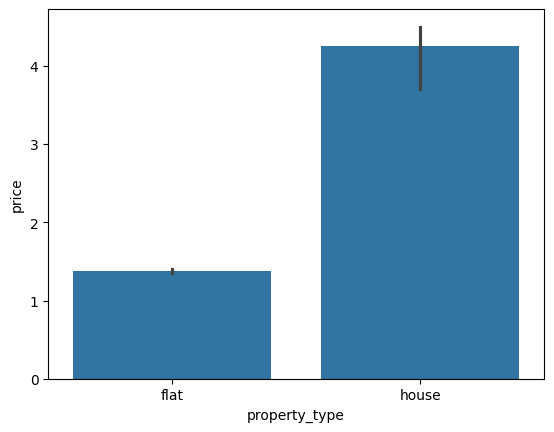

In [54]:
sns.barplot(x=df['property_type'], y=df['price'], estimator=np.median) # Houses are more expensive than flats

<Axes: xlabel='property_type', ylabel='price'>

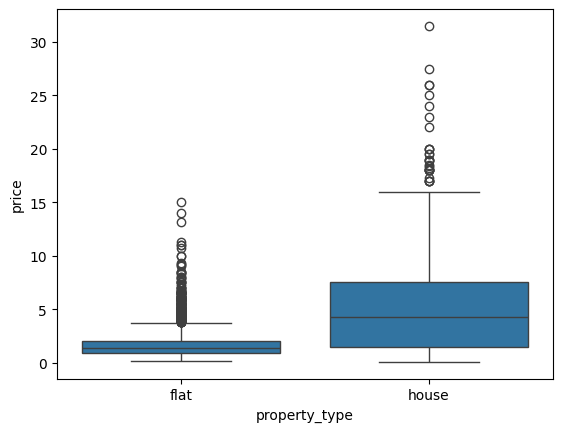

In [55]:
sns.boxplot(x=df['property_type'], y=df['price']) # range of houses is wider than flats

### property_type vs area

<Axes: xlabel='property_type', ylabel='built_up_area'>

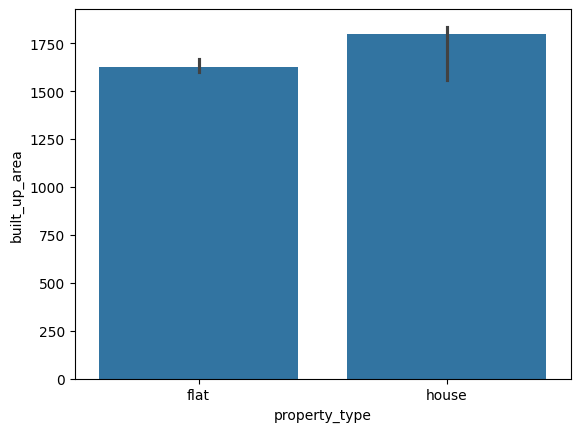

In [56]:
sns.barplot(x=df['property_type'], y=df['built_up_area'], estimator=np.median) # Houses are bigger than flats

<Axes: xlabel='property_type', ylabel='built_up_area'>

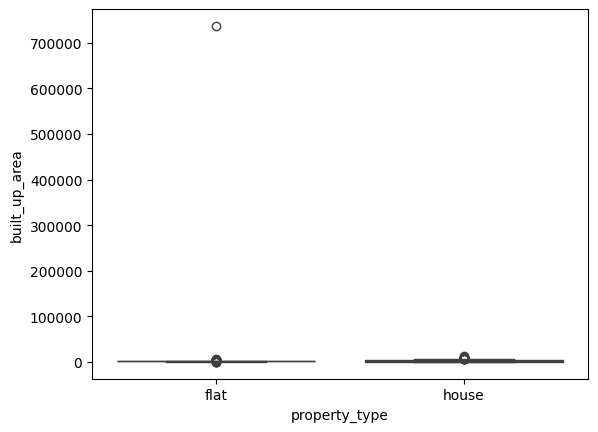

In [57]:
sns.boxplot(x=df['property_type'], y=df['built_up_area']) # unable to visualize due to one outlier

<Axes: xlabel='property_type', ylabel='built_up_area'>

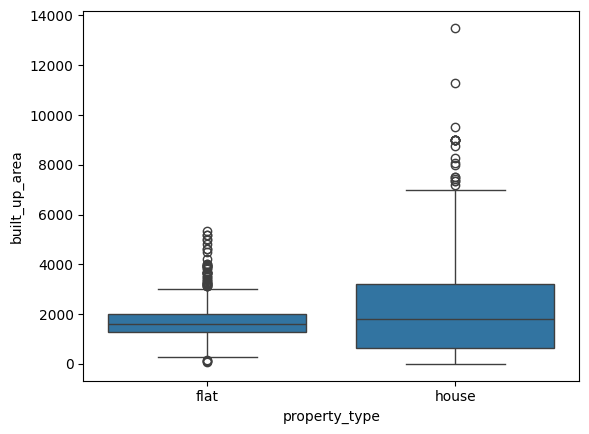

In [58]:
# removing that crazy outlier and visualizing again
df = df[df['built_up_area'] != 737147]

sns.boxplot(x=df['property_type'], y=df['built_up_area']) # range of houses area is wider than flats area

### property_type vs price_per_sqft

<Axes: xlabel='property_type', ylabel='price_per_sqft'>

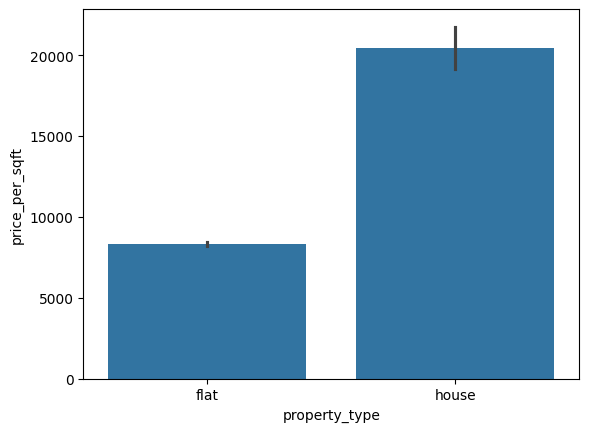

In [59]:
sns.barplot(x=df['property_type'], y=df['price_per_sqft'], estimator=np.median) # houses are more expensive than flats per sqft

<Axes: xlabel='property_type', ylabel='price_per_sqft'>

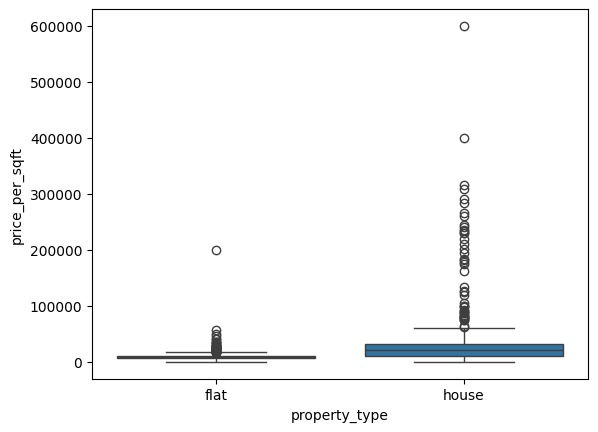

In [60]:
sns.boxplot(x=df['property_type'], y=df['price_per_sqft']) # there are outliers

In [61]:
# check outliers
df[df['price_per_sqft'] > 100000][['property_type','society','sector','price','price_per_sqft','area','areaWithType', 'super_built_up_area', 'built_up_area', 'carpet_area']]
# data errors : Incorrect area calculation leads to incorrect price per sqft calculation.

,property_type,society,sector,price,price_per_sqft,area,areaWithType,super_built_up_area,built_up_area,carpet_area
50,flat,ambience caitriona,sector 24,14.00,200000.0,700.0,Built Up area: 700 (65.03 sq.m.),NaN,700.0,NaN
255,house,rk excelo,sector 12,0.60,120000.0,50.0,Plot area 50(4.65 sq.m.)Built Up area: 30 sq.f...,NaN,30.0,15.0
363,house,ansal,sector 43,1.85,308333.0,60.0,Plot area 60(5.57 sq.m.),NaN,60.0,NaN
393,house,emaar the palm springs,sector 54,24.00,600000.0,400.0,Plot area 400(37.16 sq.m.),NaN,400.0,NaN
417,house,huda plot sector 38,sector 38,4.30,245398.0,175.0,Plot area 163(15.14 sq.m.)Built Up area: 145 s...,NaN,145.0,NaN
712,house,unitech nirvana birch court,sector 50,7.10,283333.0,251.0,Plot area 240(22.3 sq.m.),NaN,240.0,NaN
759,house,"bhim nagar, sector 6",sector 6,0.85,126865.0,67.0,Plot area 67(6.22 sq.m.),NaN,67.0,NaN
890,house,independent,sector 12,3.50,133079.0,263.0,Plot area 263(24.43 sq.m.)Built Up area: 4800 ...,NaN,4800.0,4400.0
1017,house,unitech uniworld resorts,sector 33,9.50,173992.0,546.0,Plot area 546(50.73 sq.m.),NaN,546.0,NaN
1243,house,independent,sector 38,8.00,230547.0,347.0,Built Up area: 347 (32.24 sq.m.)Carpet area: 2...,NaN,347.0,215.0


In [62]:
df.head()

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
0,flat,signature global solera,sector 107,0.36,6581.0,547.0,Carpet area: 547 (50.82 sq.m.),2,2,2,8.0,South-East,Relatively New,NaN,NaN,547.0,0,0,0,0,0,0,45
1,flat,tulip yellow,sector 69,1.80,10563.0,1704.0,Carpet area: 1704 (158.31 sq.m.),3,3,3,14.0,East,Under Construction,NaN,NaN,1704.0,0,0,0,0,0,0,49
2,flat,tulip violet,sector 69,1.75,9459.0,1850.0,Carpet area: 1850 (171.87 sq.m.),3,4,2,0.0,East,Relatively New,NaN,NaN,1850.0,0,0,0,0,0,2,174
3,flat,ardee city,sector 52,1.50,9146.0,1640.0,Super Built up area 1640(152.36 sq.m.),4,4,3,3.0,NaN,Old Property,1640.0,NaN,NaN,0,0,0,0,0,0,65
4,house,independent,sector 7,3.85,14650.0,2628.0,Plot area 292(244.15 sq.m.),4,4,3,3.0,North-West,Old Property,NaN,2628.0,NaN,0,0,0,0,0,0,27


### property_type vs bedRoom

<Axes: xlabel='bedRoom', ylabel='property_type'>

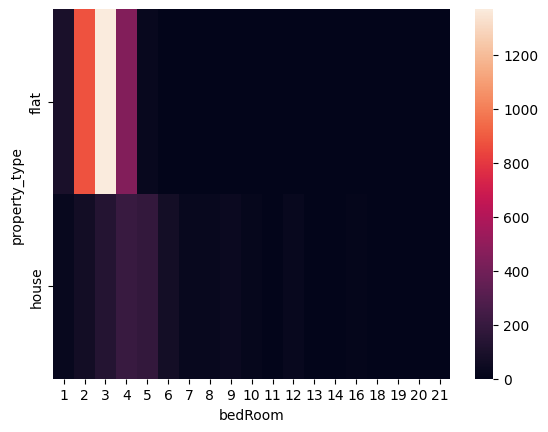

In [63]:
sns.heatmap(pd.crosstab(df['property_type'],df['bedRoom'])) # 2,2,4 are common for flats while 4,5 and 3 are common for houses.

In [64]:
# checking outliers
df[df['bedRoom'] >= 10]
# data errros : there are some errors like 21 bedRoom but area is only 1161

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
24,house,shivpuri,sector 7,2.80,12444.0,2250.0,Plot area 2250(209.03 sq.m.),10,7,3,1.0,NaN,Old Property,NaN,2250.0,NaN,1,1,0,1,1,2,0
79,house,dlf city plots phase 3,sector 24,5.00,34083.0,1467.0,Plot area 163(136.29 sq.m.),13,13,3+,4.0,North,New Property,NaN,1467.0,NaN,0,0,0,1,0,1,91
130,house,independent,sector 54,5.00,43066.0,1161.0,Plot area 129(107.86 sq.m.),21,21,3+,5.0,North,Relatively New,NaN,1161.0,NaN,0,1,0,0,0,1,49
156,house,independent,sector 26,14.75,51864.0,2844.0,Plot area 316(264.22 sq.m.),16,20,3+,4.0,East,New Property,NaN,2844.0,NaN,1,1,1,1,0,2,153
197,house,independent,sector 13,1.50,11538.0,1300.0,Plot area 1300(120.77 sq.m.),10,7,3,4.0,East,Moderately Old,NaN,1300.0,NaN,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3711,house,independent,sector 11,3.50,15555.0,2250.0,Built Up area: 2250 (209.03 sq.m.),10,1,0,1.0,NaN,New Property,NaN,2250.0,NaN,0,0,0,0,0,0,0
3721,house,independent,sector 110,8.25,45833.0,1800.0,Plot area 210(175.59 sq.m.)Built Up area: 205 ...,12,12,3+,4.0,East,New Property,NaN,205.0,200.0,0,1,0,1,0,2,40
3772,house,independent,sector 28,11.00,33951.0,3240.0,Plot area 360(301.01 sq.m.),13,13,3+,3.0,East,Relatively New,NaN,3240.0,NaN,1,1,0,1,0,1,122
3785,house,independent,sector 25,9.00,28490.0,3159.0,Plot area 351(293.48 sq.m.),10,10,3,3.0,East,Old Property,NaN,3159.0,NaN,0,0,0,1,0,2,64


<Axes: xlabel='bedRoom', ylabel='property_type'>

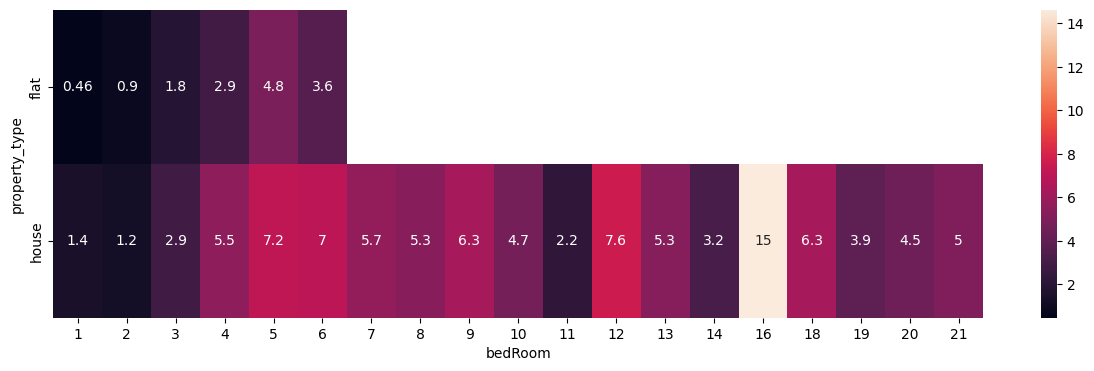

In [65]:
plt.figure(figsize=(15,4))
sns.heatmap(pd.pivot_table(df,index='property_type',columns='bedRoom',values='price',aggfunc='mean'),annot=True)
# price of flat increases on increasing bedRoom
# price of house increases on increasing bedRoom max price at 16 bedRoom and 11, 12, 19 bedRoom houses are cheaper that might be data error

### property_type vs floorNum

<Axes: xlabel='property_type', ylabel='floorNum'>

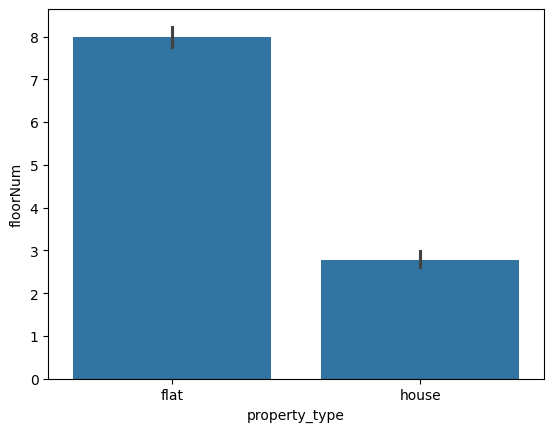

In [66]:
sns.barplot(x=df['property_type'],y=df['floorNum'])
# flats have higher number of floorNum than houses

<Axes: xlabel='property_type', ylabel='floorNum'>

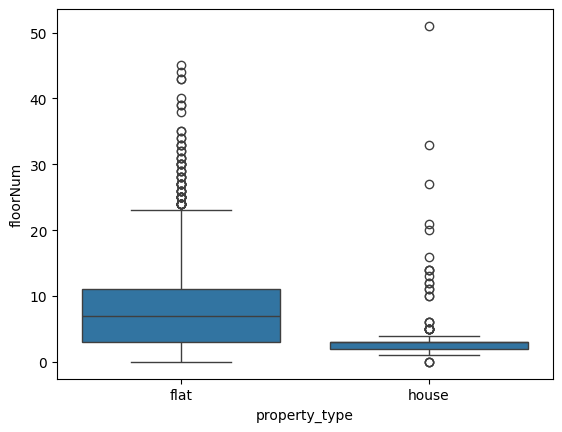

In [67]:
sns.boxplot(x=df['property_type'],y=df['floorNum'])
# there are outliers in the houses floorNum data

In [68]:
# checking for outliers
df[(df['property_type'] == 'house') & (df['floorNum'] > 10)]
# houses have more than 10 floorNum because the houses are on the top of apartment i.e. houses(villa) but in appartments

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
11,house,suncity township,sector 54,2.00,30968.0,646.0,Plot area 60Built Up area: 60 sq.m.Carpet area...,9,9,3,11.0,North,Relatively New,NaN,60.0,59.0,0,1,0,0,0,1,7
122,house,greenopolis,sector 89,0.70,5397.0,1297.0,Built Up area: 1297 (120.5 sq.m.),2,2,2,14.0,North-East,Undefined,NaN,1297.0,NaN,0,0,0,0,0,0,0
328,house,independent,sector 92,1.80,7627.0,2360.0,Built Up area: 2360 (219.25 sq.m.),4,5,0,13.0,NaN,Undefined,NaN,2360.0,NaN,0,0,0,0,0,0,0
362,house,vatika the seven lamps,sector 82,1.60,6597.0,2425.0,Plot area 2425(225.29 sq.m.),4,4,3+,16.0,North,Moderately Old,NaN,2425.0,NaN,0,1,0,0,0,0,94
801,house,dlf the arbour,sector 63,8.50,21519.0,3950.0,Built Up area: 3950 (366.97 sq.m.),4,4,3+,27.0,NaN,Undefined,NaN,3950.0,NaN,0,0,0,0,0,0,61
952,house,indiabulls centrum park,sector 103,3.25,8125.0,4000.0,Plot area 4000(371.61 sq.m.),4,3,3+,20.0,NaN,Under Construction,NaN,4000.0,NaN,0,0,0,0,0,0,51
1214,house,satya the hermitage,sector 103,3.15,6702.0,4700.0,Built Up area: 4700 (436.64 sq.m.),4,5,0,12.0,East,Undefined,NaN,4700.0,NaN,0,0,0,0,0,0,61
1607,house,suncity avenue 76,sector 76,0.75,10067.0,745.0,Plot area 745(69.21 sq.m.)Built Up area: 745 s...,2,2,2,11.0,North-East,New Property,NaN,745.0,NaN,0,0,0,0,0,0,40
1750,house,spaze privy,sector 72,3.09,6981.0,4426.0,Built Up area: 3653 (339.37 sq.m.)Carpet area:...,5,5,3+,14.0,East,Relatively New,NaN,3653.0,2922.0,0,1,0,0,0,2,33
1788,house,ats tourmaline,sector 109,1.87,8697.0,2150.0,Built Up area: 2150 (199.74 sq.m.),3,4,0,12.0,NaN,Undefined,NaN,2150.0,NaN,0,0,0,0,0,0,0


### property_type vs agePossession

<Axes: xlabel='agePossession', ylabel='property_type'>

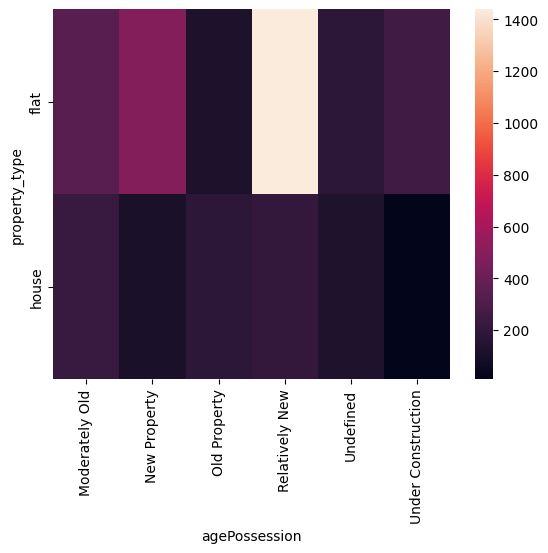

In [69]:
sns.heatmap(pd.crosstab(df['property_type'],df['agePossession']))
# flats are generally newer and most new construction are flats

<Axes: xlabel='agePossession', ylabel='property_type'>

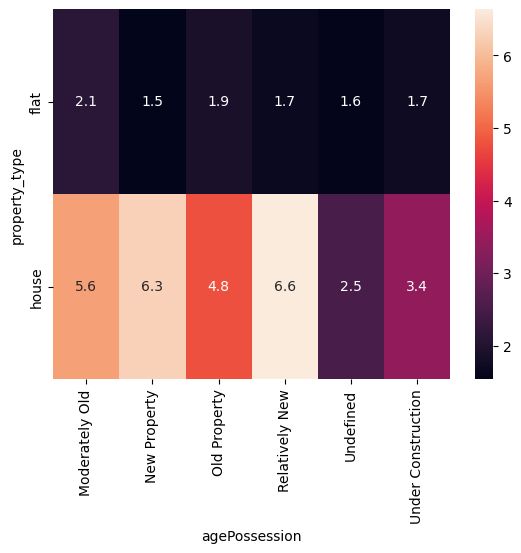

In [70]:
sns.heatmap(pd.pivot_table(df,index='property_type',columns='agePossession',values='price',aggfunc='mean'),annot=True)
# houses are generally more expensive than flats
# new houses are most expensive and new flats are least expensive

### property_type vs furnishing_type

<Axes: xlabel='furnishing_type', ylabel='property_type'>

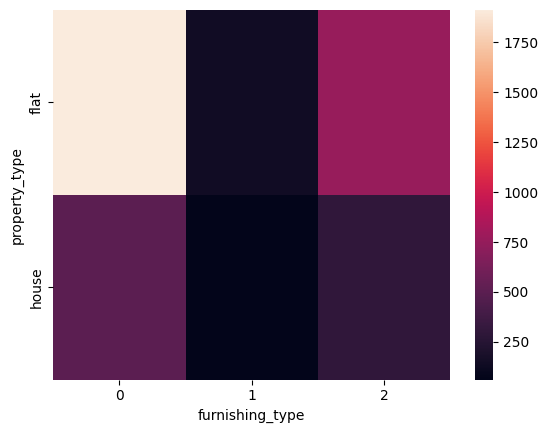

In [71]:
sns.heatmap(pd.crosstab(df['property_type'],df['furnishing_type']))
# unfurnished > furnished > semi-furnished for both flats and houses

<Axes: xlabel='furnishing_type', ylabel='property_type'>

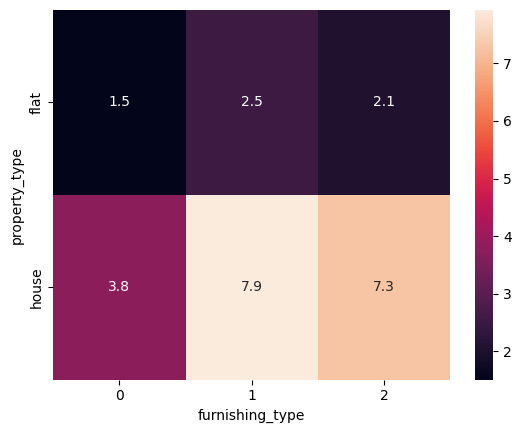

In [72]:
sns.heatmap(pd.pivot_table(df,index='property_type',columns='furnishing_type',values='price',aggfunc='mean'),annot=True)
# unfurnished flats and houses are cheaper while semi-furnihsed flats and houses are most expensive

### property_type vs luxury_score

<Axes: xlabel='property_type', ylabel='luxury_score'>

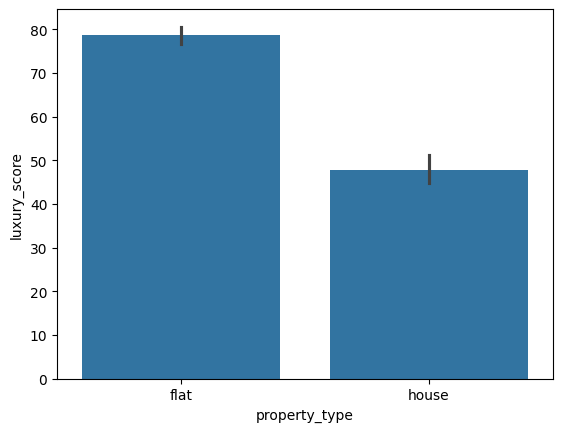

In [73]:
sns.barplot(x=df['property_type'],y=df['luxury_score'])
# flats are more luxurious than houses

<Axes: xlabel='property_type', ylabel='luxury_score'>

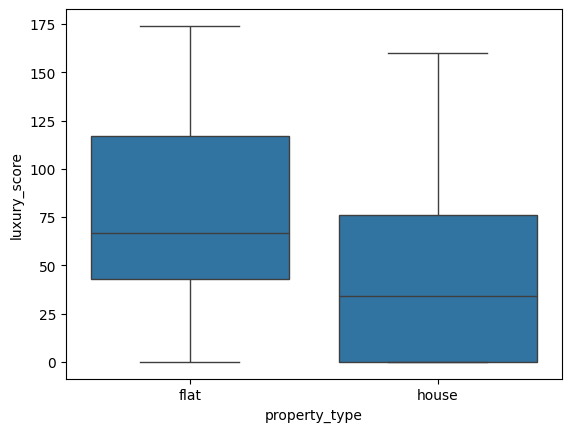

In [74]:
sns.boxplot(x=df['property_type'],y=df['luxury_score'])
# no outliers in luxury score data

### property_type vs sector

<Axes: xlabel='sector', ylabel='property_type'>

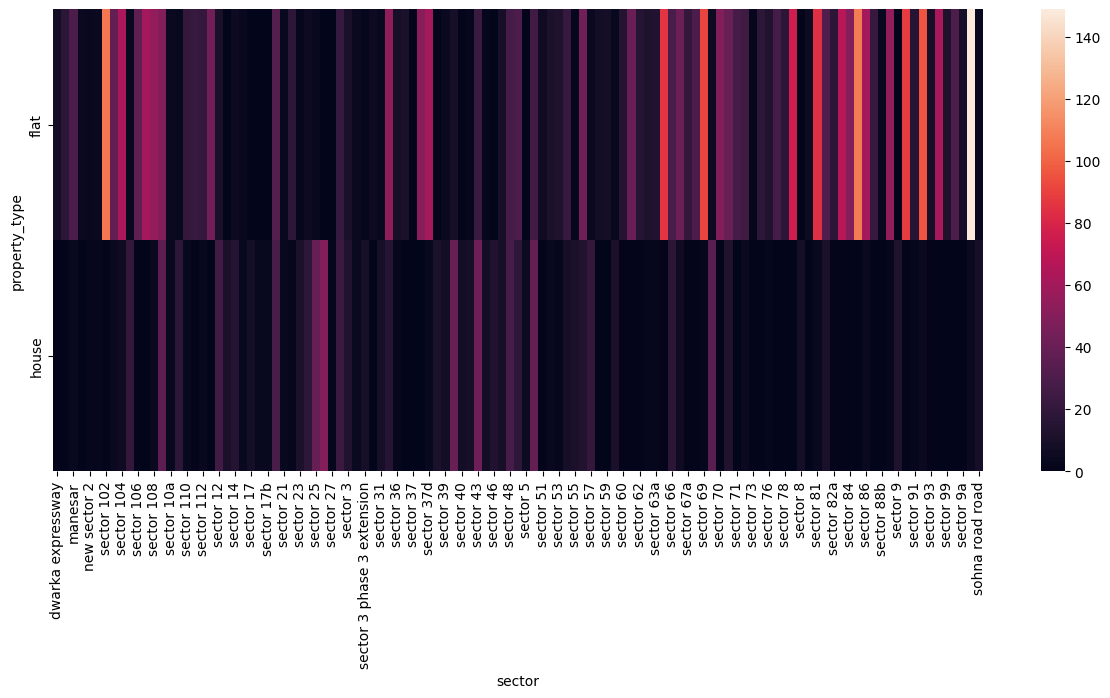

In [75]:
plt.figure(figsize=(15,6))
sns.heatmap(pd.crosstab(df['property_type'],df['sector'].sort_index()))
# above 65 are new sectors thus most building are flats
# below 65 are old sectors thus most building are houses 

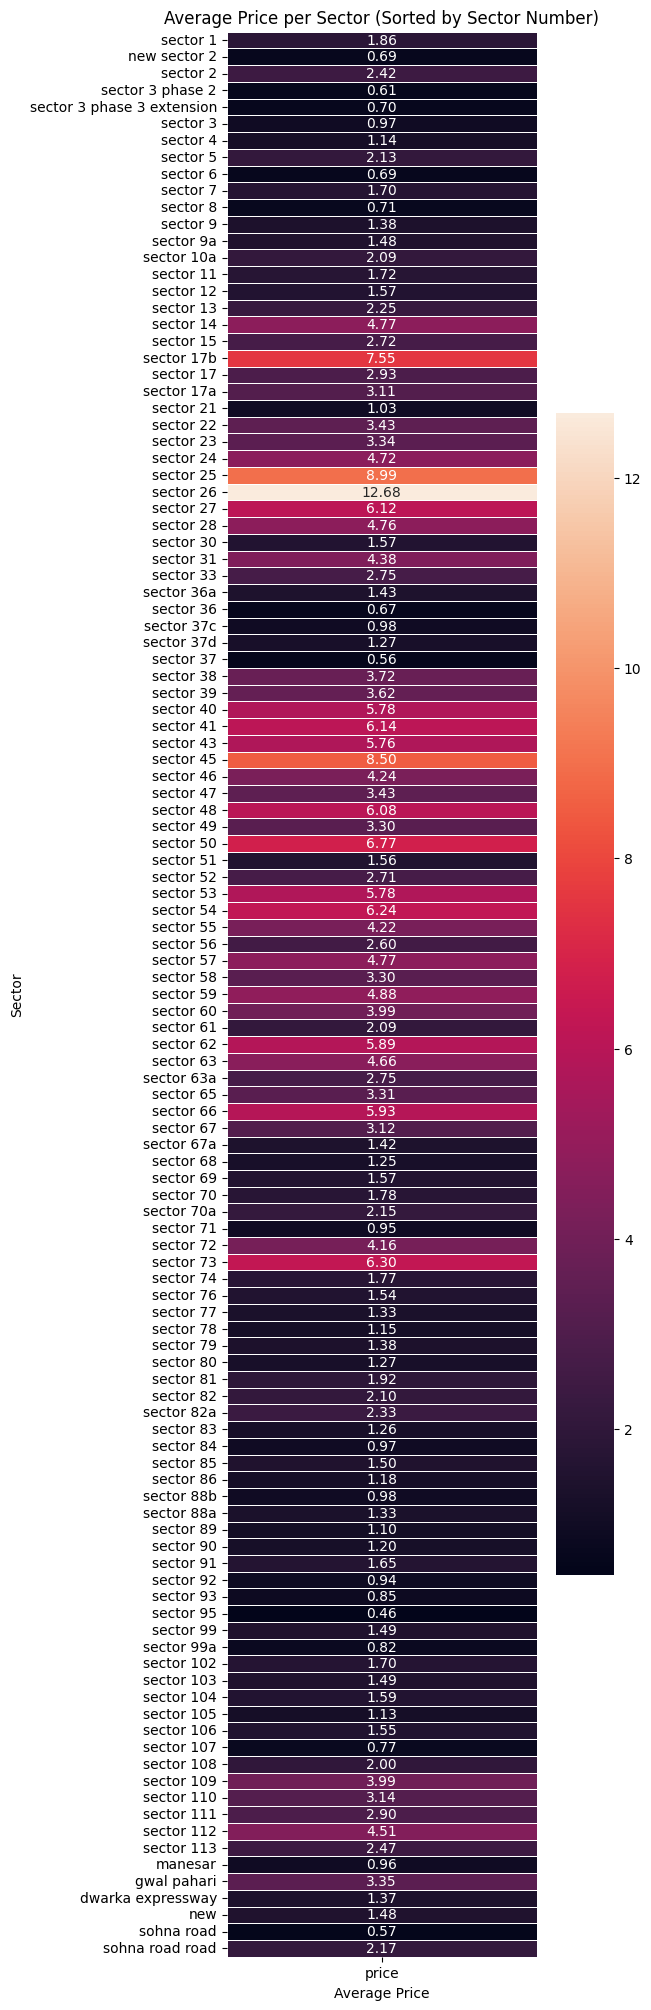

In [76]:
# Group by 'sector' and calculate the average price
avg_price_per_sector = df.groupby('sector')['price'].mean().reset_index()

# Function to extract sector numbers
def extract_sector_number(sector_name):
    match = re.search(r'\d+', sector_name)
    if match:
        return int(match.group())
    else:
        return float('inf')  # Return a large number for non-numbered sectors

avg_price_per_sector['sector_number'] = avg_price_per_sector['sector'].apply(extract_sector_number)

# Sort by sector number
avg_price_per_sector_sorted_by_sector = avg_price_per_sector.sort_values(by='sector_number')

# Plot the heatmap
plt.figure(figsize=(5, 25))
sns.heatmap(avg_price_per_sector_sorted_by_sector.set_index('sector')[['price']], annot=True, fmt=".2f", linewidths=.5)
plt.title('Average Price per Sector (Sorted by Sector Number)')
plt.xlabel('Average Price')
plt.ylabel('Sector')
plt.show()

sectors 14 to 31 are old sectors but costly
sectors 38 to 67 are reletively new sectors but costly 

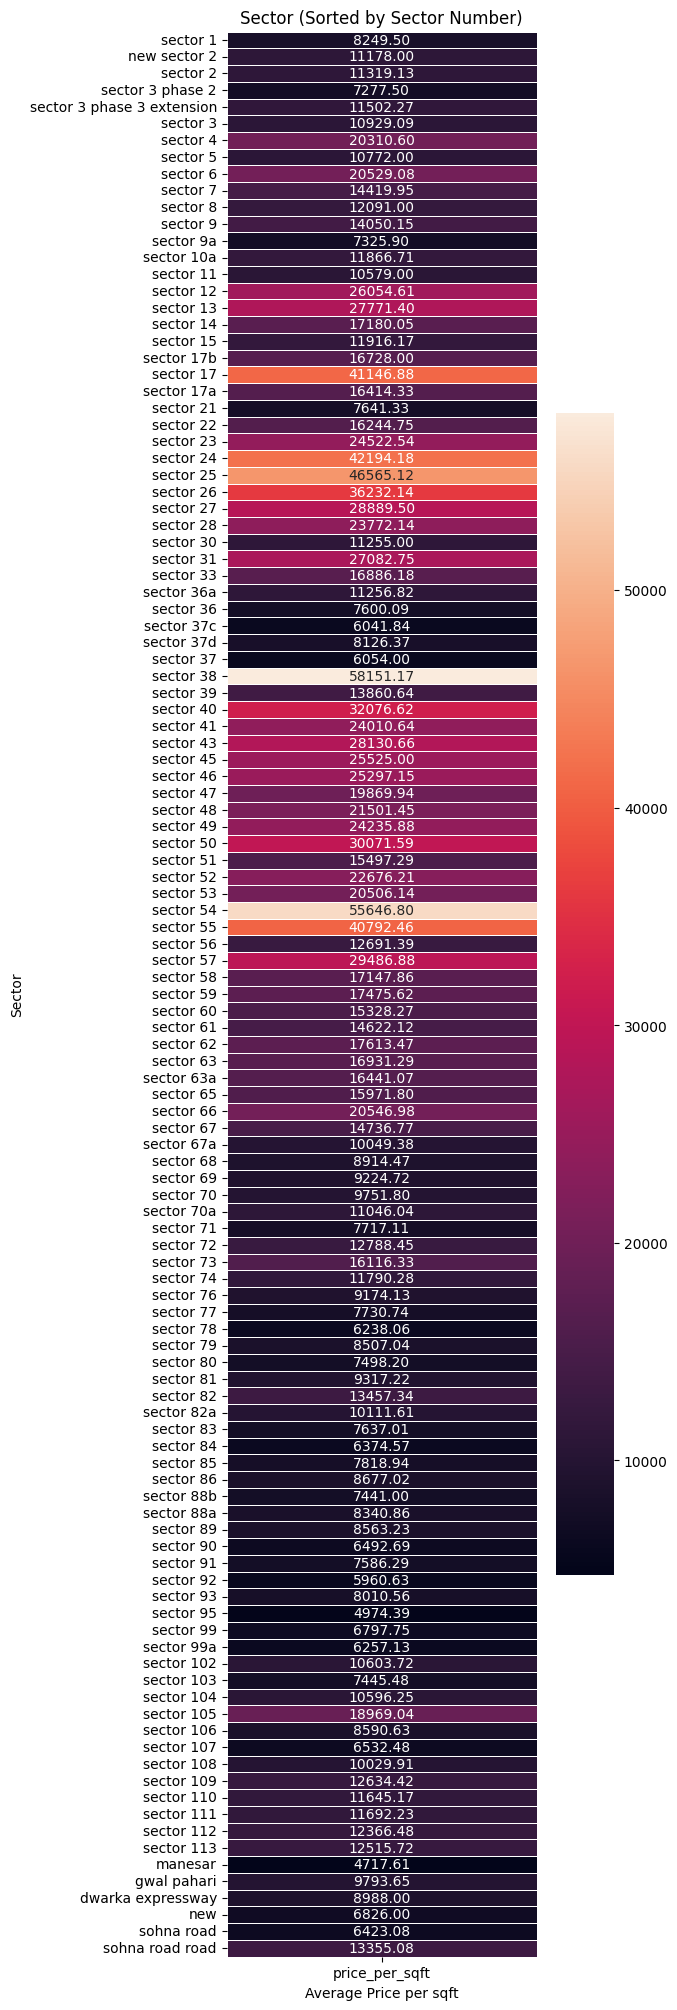

In [77]:
avg_price_per_sqft_sector = df.groupby('sector')['price_per_sqft'].mean().reset_index()

avg_price_per_sqft_sector['sector_number'] = avg_price_per_sqft_sector['sector'].apply(extract_sector_number)

# Sort by sector number
avg_price_per_sqft_sector_sorted_by_sector = avg_price_per_sqft_sector.sort_values(by='sector_number')

# Plot the heatmap
plt.figure(figsize=(5, 25))
sns.heatmap(avg_price_per_sqft_sector_sorted_by_sector.set_index('sector')[['price_per_sqft']], annot=True, fmt=".2f", linewidths=.5)
plt.title('Sector (Sorted by Sector Number)')
plt.xlabel('Average Price per sqft')
plt.ylabel('Sector')
plt.show()

Same as above

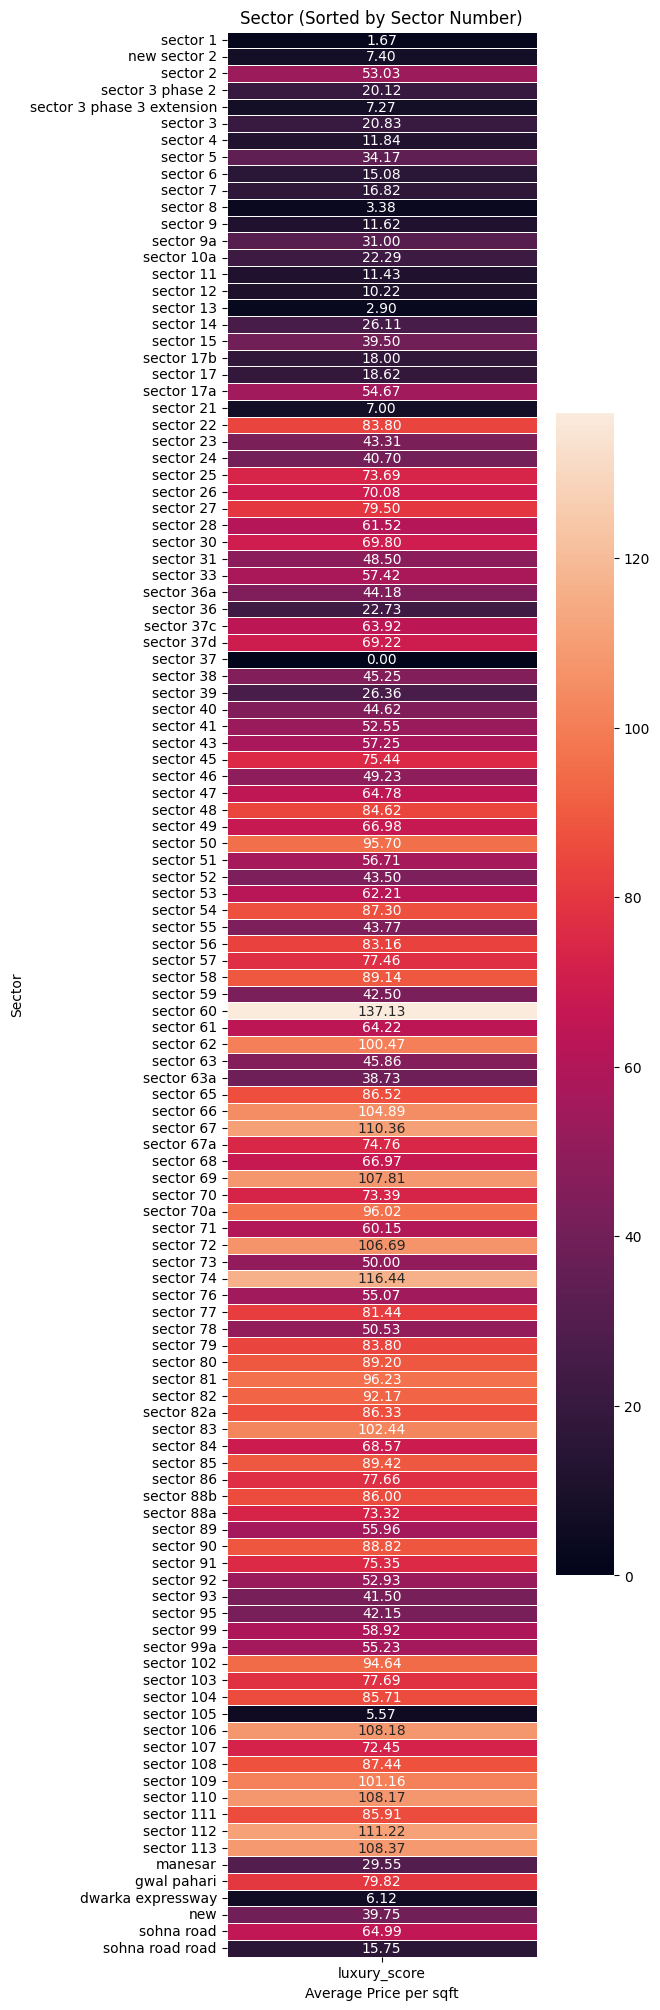

In [78]:
luxury_score = df.groupby('sector')['luxury_score'].mean().reset_index()

luxury_score['sector_number'] = luxury_score['sector'].apply(extract_sector_number)

# Sort by sector number
luxury_score_sector = luxury_score.sort_values(by='sector_number')

# Plot the heatmap
plt.figure(figsize=(5, 25))
sns.heatmap(luxury_score_sector.set_index('sector')[['luxury_score']], annot=True, fmt=".2f", linewidths=.5)
plt.title('Sector (Sorted by Sector Number)')
plt.xlabel('Average Price per sqft')
plt.ylabel('Sector')
plt.show()

new sectors are more luxurious

### area vs price vs bedRoom

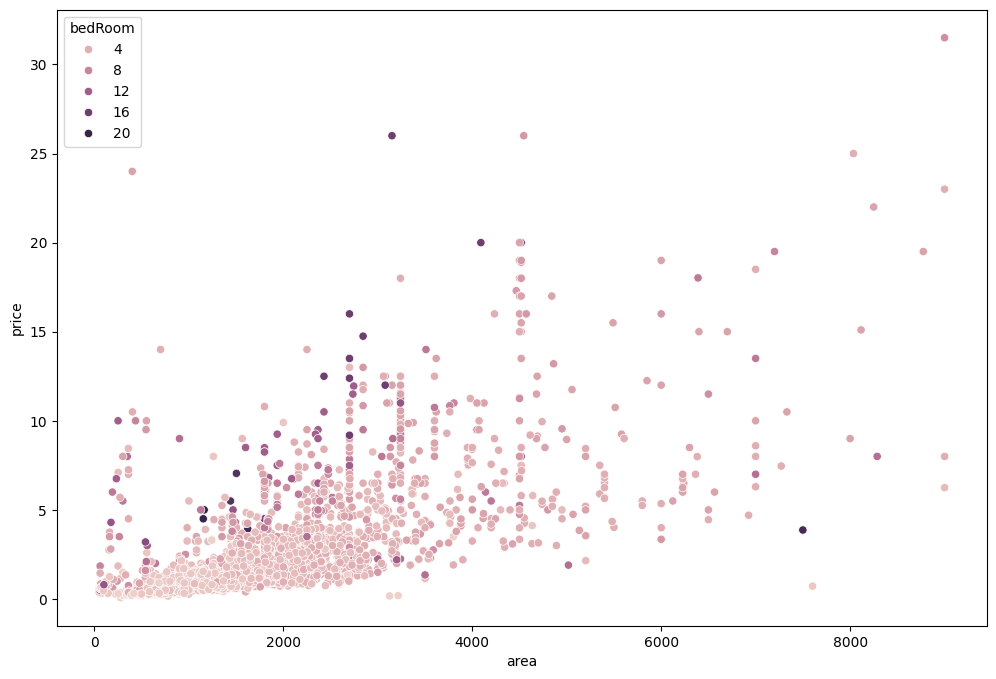

In [79]:
plt.figure(figsize=(12,8))
sns.scatterplot(x=df[df['area']<10000]['area'],y=df['price'],hue=df['bedRoom'])
plt.show()
# there is linear relationship between area and price and more bedRoom means more price

### area vs price vs agePossession

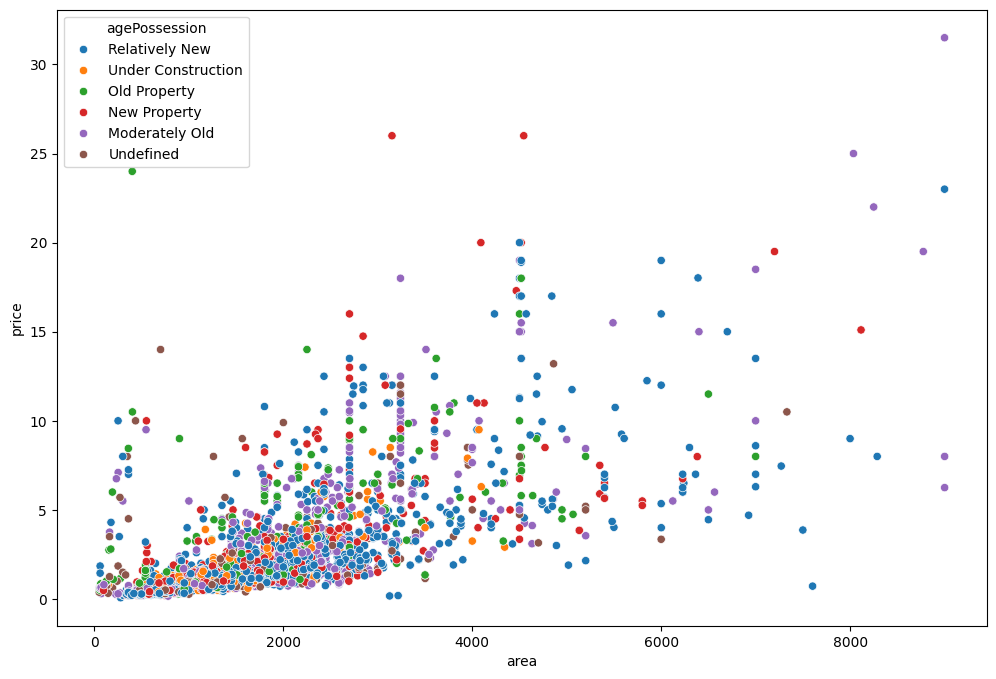

In [80]:
plt.figure(figsize=(12,8))
sns.scatterplot(x=df[df['area']<10000]['area'],y=df['price'],hue=df['agePossession'])
plt.show()
# no clear pattern

### area vs price vs furnishing_type

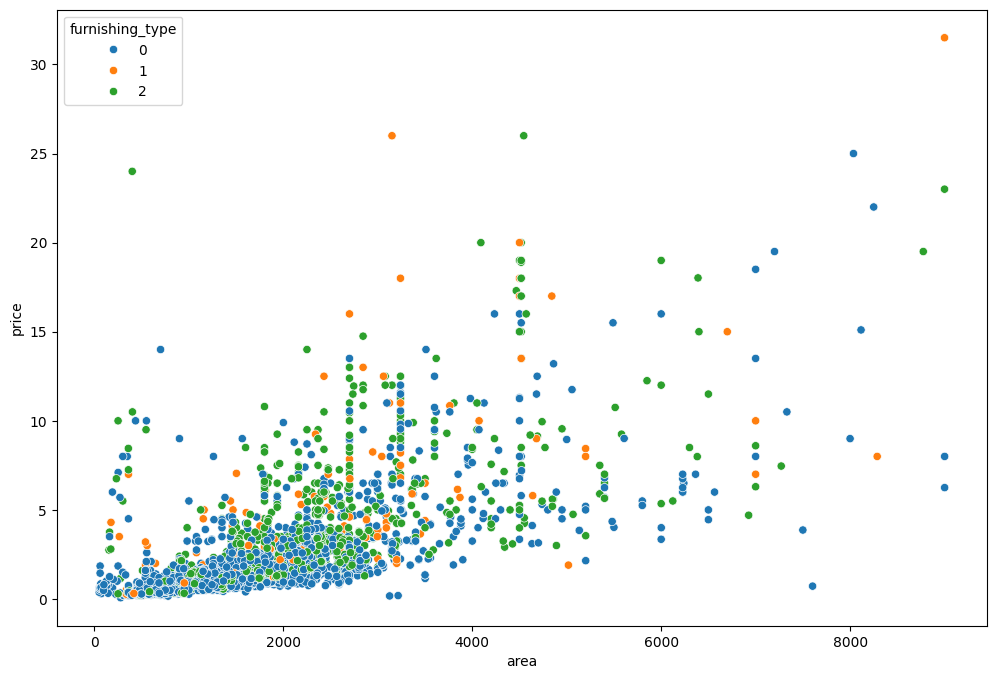

In [81]:
plt.figure(figsize=(12,8))
sns.scatterplot(x=df[df['area']<10000]['area'],y=df['price'],hue=df['furnishing_type'].astype('category'))
plt.show()
# generally 2 furnished are most costly, 0 unfurnished are least costly and 1 semi-furnished are in between

### price vs bedRoom

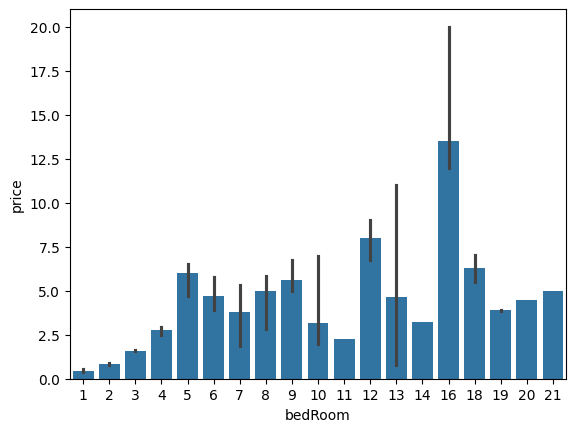

In [82]:
sns.barplot(x=df['bedRoom'],y=df['price'],estimator=np.median)
plt.show()
# price increases with increasing bedRoom

### agePossession vs price

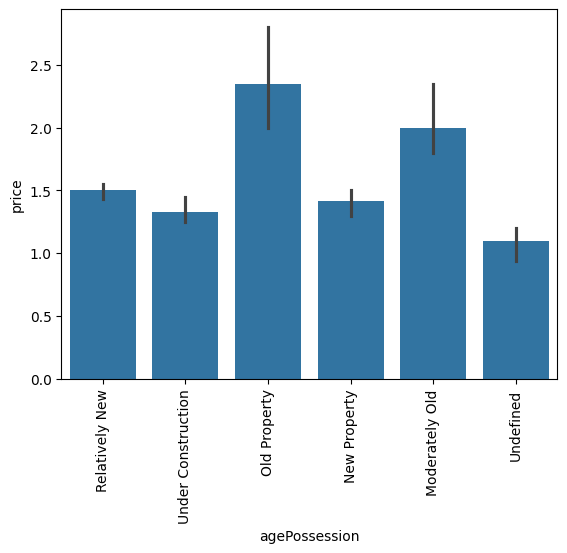

In [83]:
sns.barplot(x=df['agePossession'],y=df['price'],estimator=np.median)
plt.xticks(rotation='vertical')
plt.show()
# under construction is cheaper while older properties (bigger and porch places) are more expensive

### agePossession vs area

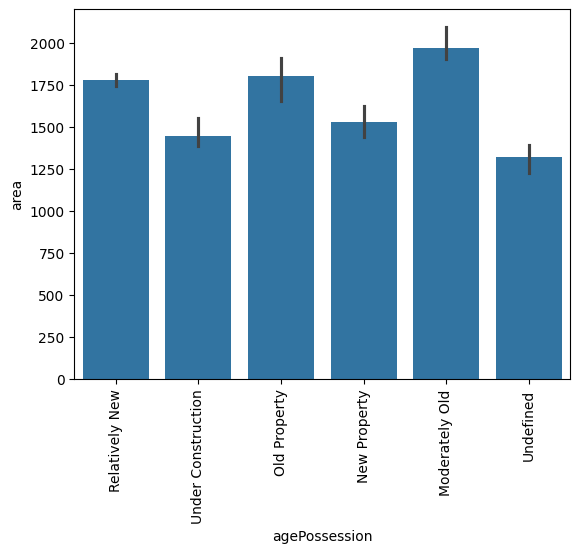

In [84]:
sns.barplot(x=df['agePossession'],y=df['area'],estimator=np.median)
plt.xticks(rotation='vertical')
plt.show()
# same as above

### furnishing_type vs price

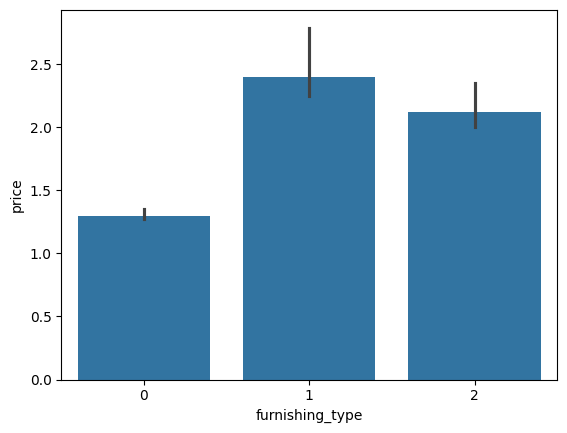

In [85]:
sns.barplot(x=df['furnishing_type'],y=df['price'],estimator=np.median)
plt.show()
# more the furnished more the price

### luxury_score vs price

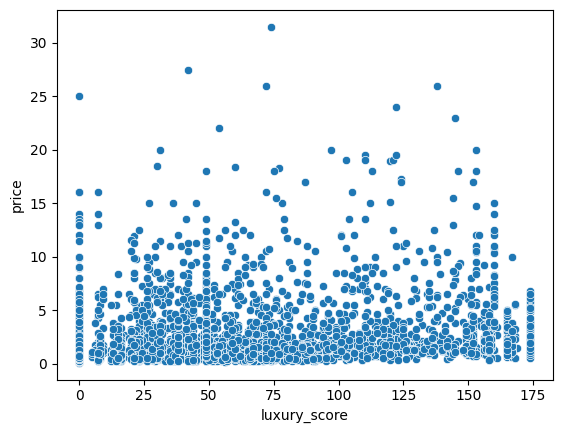

In [86]:
sns.scatterplot(x=df['luxury_score'],y=df['price'])
plt.show()
# no good pattern for luxury score and price relationship

### correlation

<Axes: >

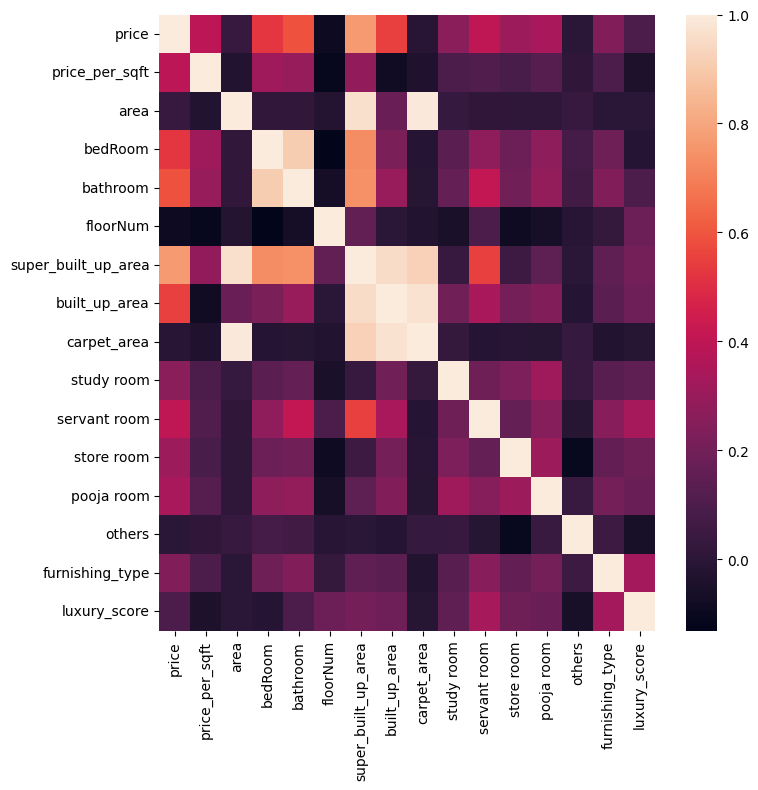

In [87]:
plt.figure(figsize=(8,8))
sns.heatmap(df.corr(numeric_only=True))

- bathRoom and bedRoom are highly correlated.
- all area are highly correlated to each other.
- super built up area are highly correlated to price, bedRoom and bathRoom.

In [89]:
df.corr(numeric_only=True)['price'].sort_values(ascending=False)

price                  1.000000
super_built_up_area    0.769412
bathroom               0.589875
built_up_area          0.551726
bedRoom                0.522968
servant room           0.401013
price_per_sqft         0.391277
pooja room             0.341560
store room             0.309169
study room             0.258681
furnishing_type        0.239231
luxury_score           0.094805
area                   0.034732
others                -0.003447
carpet_area           -0.011322
floorNum              -0.094150
Name: price, dtype: float64

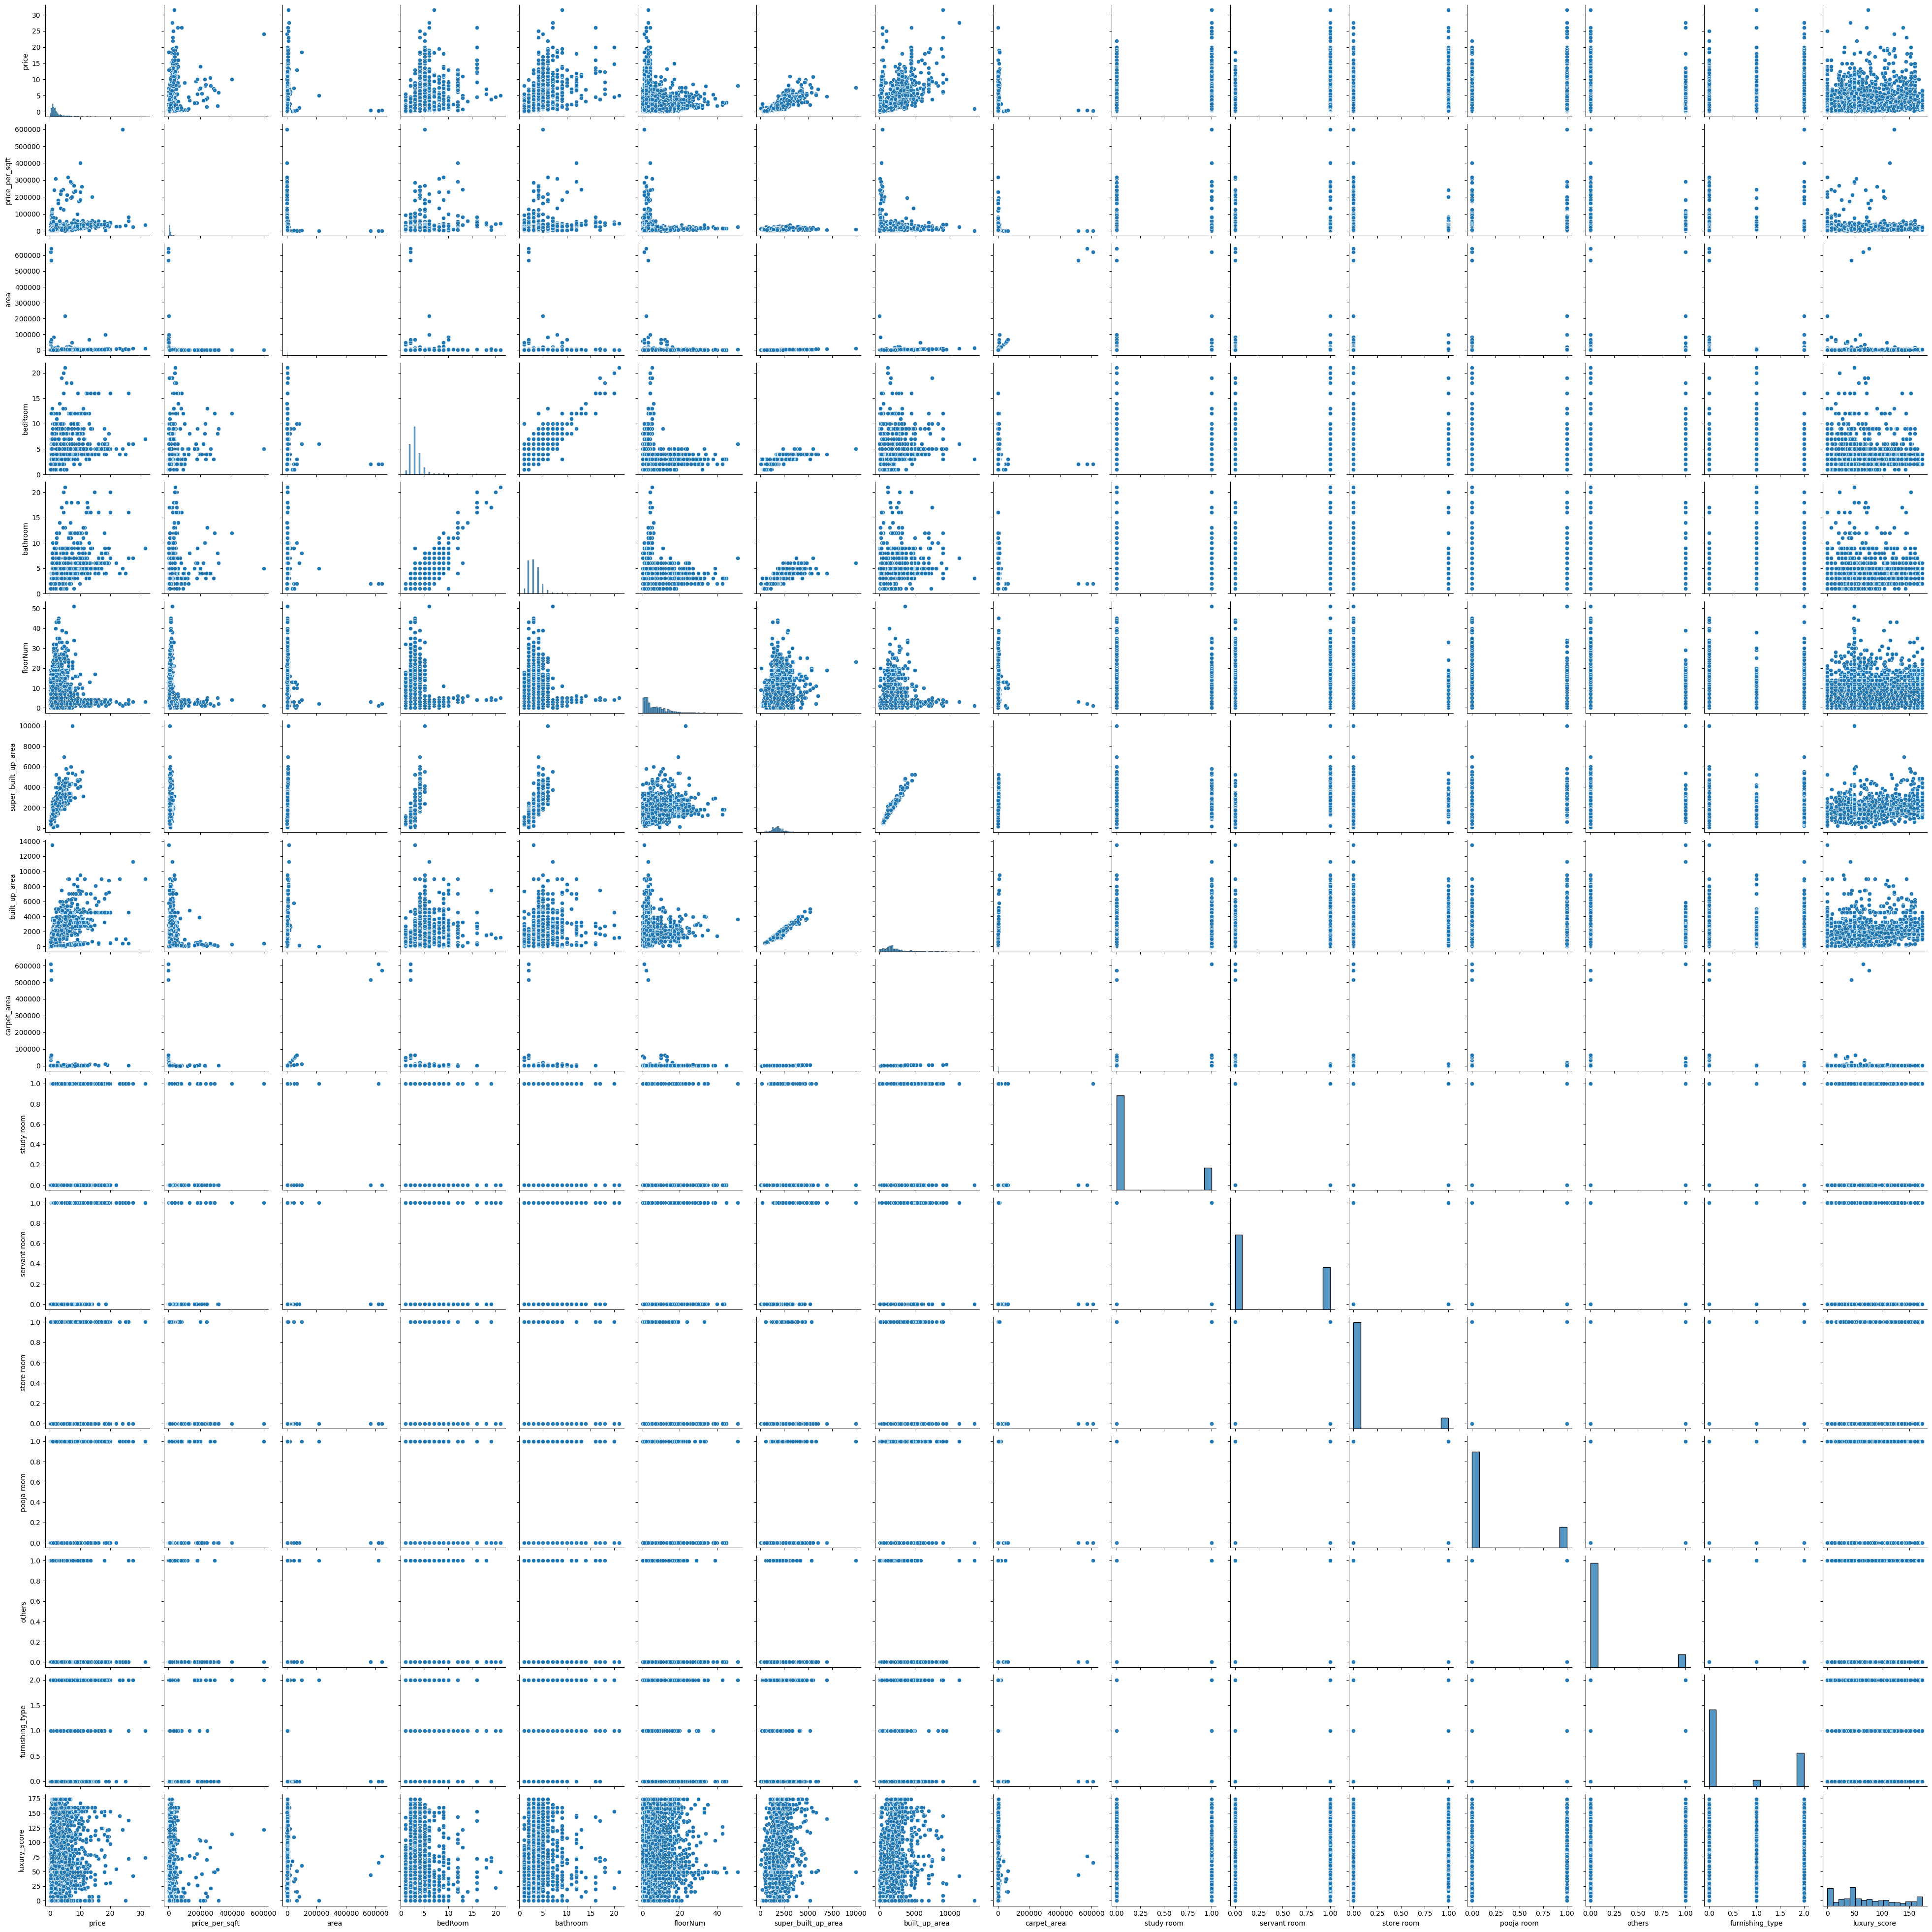

In [90]:
sns.pairplot(df)
plt.show()